# Embedding Geometry Analysis

Compare raw neural geometry, no-category shared latent geometry, predicted embedding geometry, GT embedding geometry, and category geometry on the HVM test split.

In [14]:
from pathlib import Path
import sys

import pandas as pd
import torch
from IPython.display import display
import matplotlib.pyplot as plt

sys.path.append('.')

from scripts.embedding_geometry_analysis import (
    compute_nn_overlap,
    compute_rdms,
    compute_rsa_tables,
    collect_geometry_data,
    plot_heatmap,
    plot_nn_overlap,
    print_key_tables,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 3)

## Configuration

`SAVE_RESULTS` is off by default. Turn it on only when you explicitly want CSV/PNG files written.

In [15]:
GLOBAL_CHECKPOINT = None  # Path("checkpoints/multihead/hvm_cat/.../best.pt") or None for cached best global model
OBJECT_CHECKPOINT = None  # Path("checkpoints/multihead/hvm_obj_cat/.../best.pt") or None for cached best object model
SPLIT_SEED = None  # None uses checkpoint args when present, else 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
RAW_WINDOW_MS = (60, 200)

SAVE_RESULTS = False
OUT_DIR = Path("results") / "embedding_geometry"

DEVICE

'cuda'

## Load Representations

This reconstructs test-set outputs from the separate global and object MultiHeadTransformer checkpoints. Category conditioning is removed by calling each model with `cat=None`.

In [16]:
class Args:
    global_checkpoint = GLOBAL_CHECKPOINT
    object_checkpoint = OBJECT_CHECKPOINT
    split_seed = SPLIT_SEED
    device = DEVICE
    batch_size = BATCH_SIZE
    raw_window_ms = RAW_WINDOW_MS


data = collect_geometry_data(Args)

print(f"global_checkpoint: {data.global_checkpoint}")
print(f"object_checkpoint: {data.object_checkpoint}")
print(f"split_seed: {data.split_seed} | raw_window_ms: {data.raw_window_ms}")
print("representations:")
for name, arr in data.reps.items():
    print(f"  {name:20s} {arr.shape}")

Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.65it/s]


HVM multihead loaders (all monkeys): train=270, val=90, test=90, neurons=2330, time=25, targets=(siglip=1152, siglip_obj=1152, clip_short=768) [stratified by category]


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


global_checkpoint: /home/yy3658/NeurObjectGen/checkpoints/multihead/hvm_cat/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_ws1.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt
object_checkpoint: /home/yy3658/NeurObjectGen/checkpoints/multihead/hvm_obj_cat/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs64_ws5.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt
split_seed: 42 | raw_window_ms: (60, 200)
representations:
  raw_neural           (90, 2330)
  shared_global_latent (90, 512)
  shared_object_latent (90, 512)
  pred_global_siglip   (90, 1152)
  pred_object_siglip   (90, 1152)
  pred_clip_global_model (90, 768)
  pred_clip_object_model (90, 768)
  gt_global_siglip     (90, 1152)
  gt_object_siglip     (90, 1152)
  gt_clip              (90, 768)


## RSA

In [17]:
rdms = compute_rdms(data)
rsa_summary, rsa_all_df, rsa_all_matrix, rsa_within_matrix = compute_rsa_tables(rdms, data.categories)

main_rsa = rsa_summary[rsa_summary["is_main_comparison"]].reset_index(drop=True)
display(main_rsa)

,pair_scope,source,reference,spearman_r,is_main_comparison
0,all_pairs,raw_neural,gt_global_siglip,7.319e-02,True
1,all_pairs,raw_neural,gt_object_siglip,2.370e-02,True
2,all_pairs,shared_global_latent,gt_global_siglip,1.189e-01,True
3,all_pairs,shared_object_latent,gt_object_siglip,7.431e-02,True
4,all_pairs,pred_global_siglip,gt_global_siglip,1.057e-01,True
5,all_pairs,pred_object_siglip,gt_object_siglip,8.878e-02,True
6,all_pairs,pred_clip_global_model,gt_clip,8.618e-02,True
7,all_pairs,pred_clip_object_model,gt_clip,9.874e-02,True
8,within_category,raw_neural,gt_global_siglip,5.549e-02,True
9,within_category,raw_neural,gt_object_siglip,5.839e-04,True


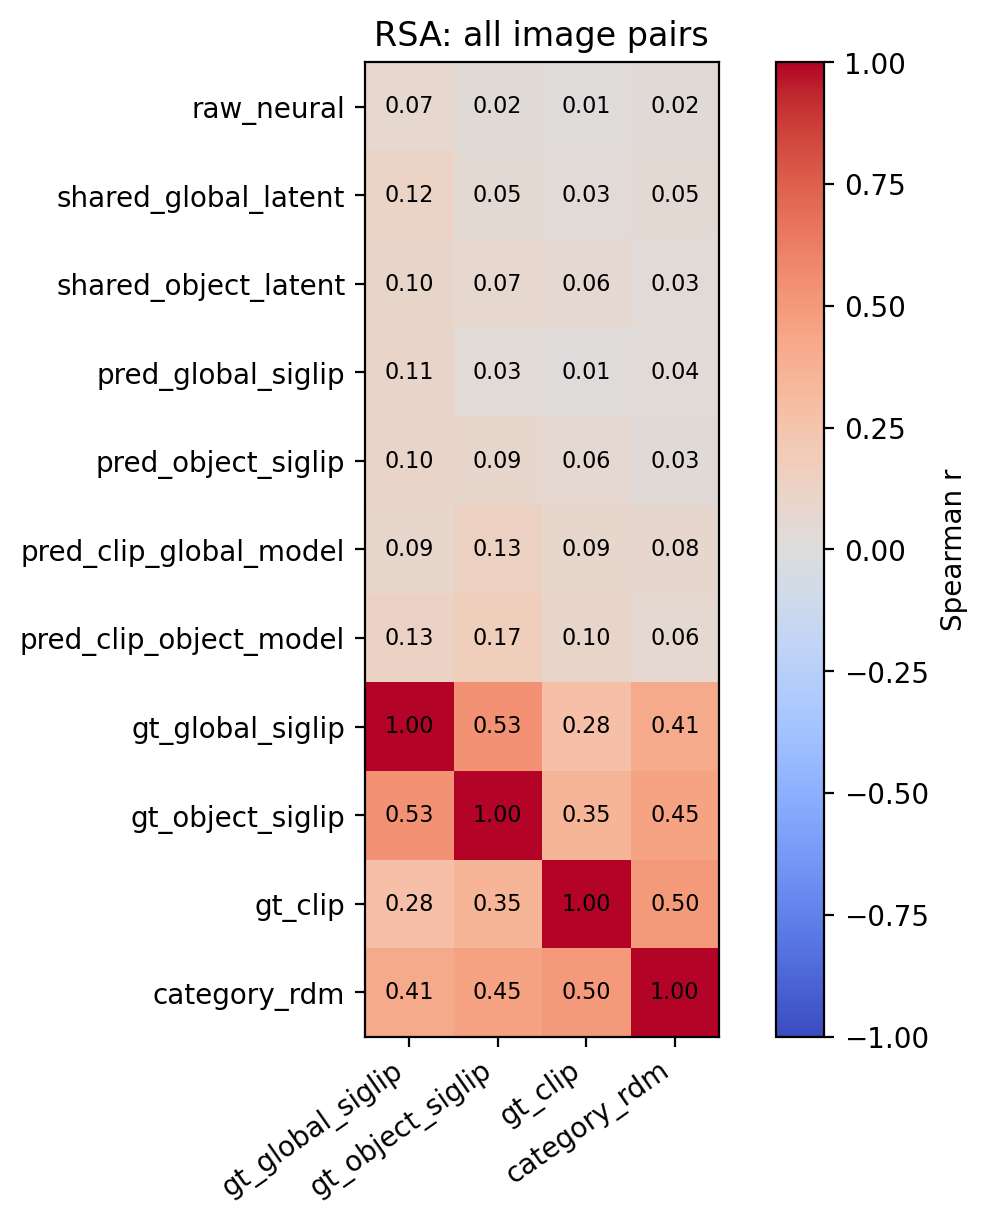

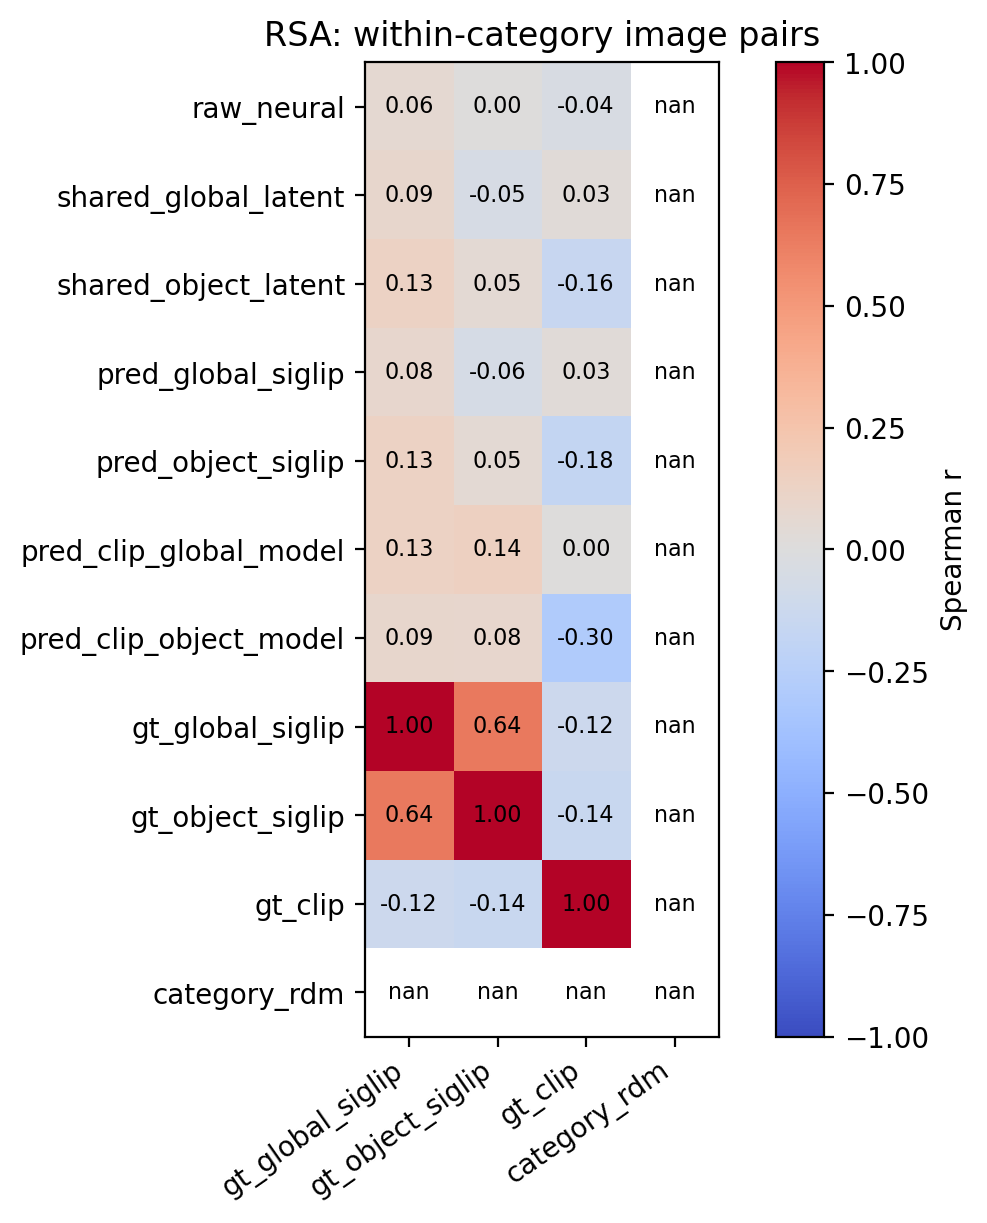

In [18]:
fig_all = plot_heatmap(rsa_all_matrix, "RSA: all image pairs")
display(fig_all)

fig_within = plot_heatmap(rsa_within_matrix, "RSA: within-category image pairs")
display(fig_within)

## Nearest-Neighbor Preservation

In [19]:
nn_summary = compute_nn_overlap(data)
display(nn_summary)

,source,source_base,reference,k,overlap,is_shuffled
0,raw_neural,raw_neural,gt_global_siglip,1,0.067,False
1,raw_neural,raw_neural,gt_global_siglip,5,0.118,False
2,raw_neural,raw_neural,gt_global_siglip,10,0.160,False
3,raw_neural,raw_neural,gt_object_siglip,1,0.067,False
4,raw_neural,raw_neural,gt_object_siglip,5,0.084,False
...,...,...,...,...,...,...
79,pred_clip_object_model_shuffled,pred_clip_object_model,gt_global_siglip,5,0.051,True
80,pred_clip_object_model_shuffled,pred_clip_object_model,gt_global_siglip,10,0.117,True
81,pred_clip_object_model_shuffled,pred_clip_object_model,gt_object_siglip,1,0.000,True
82,pred_clip_object_model_shuffled,pred_clip_object_model,gt_object_siglip,5,0.060,True


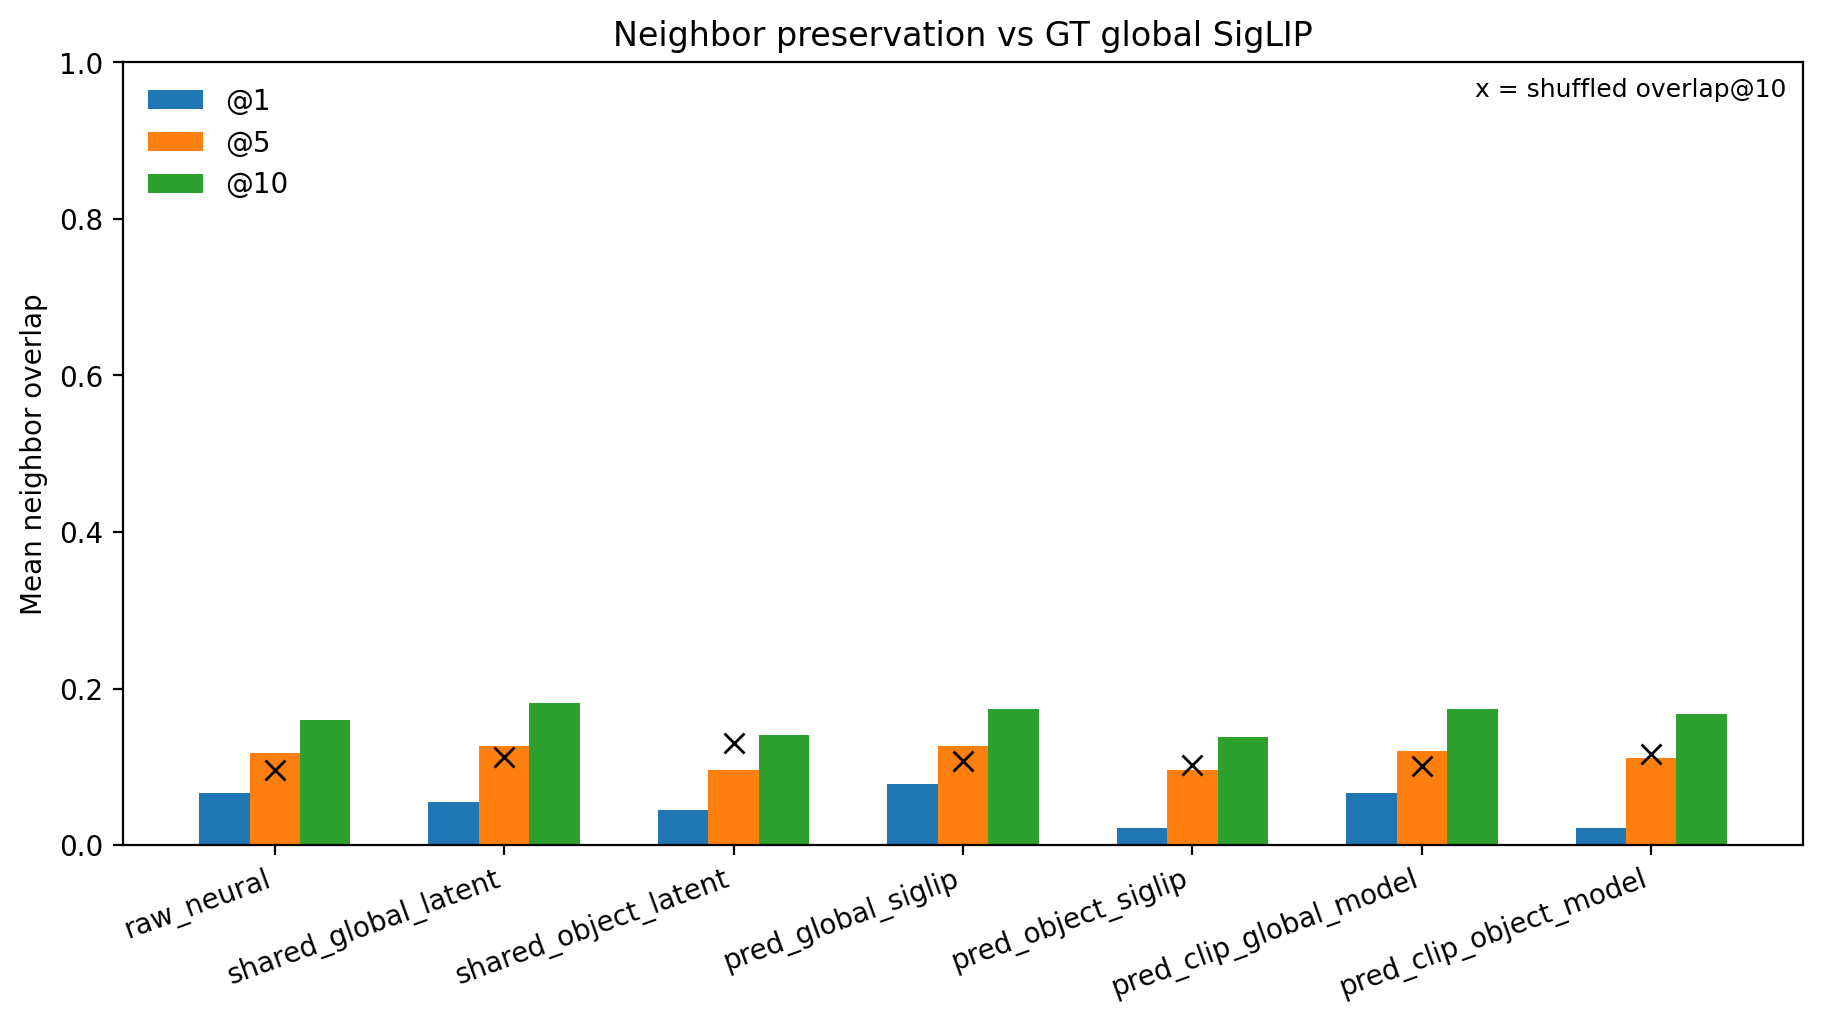

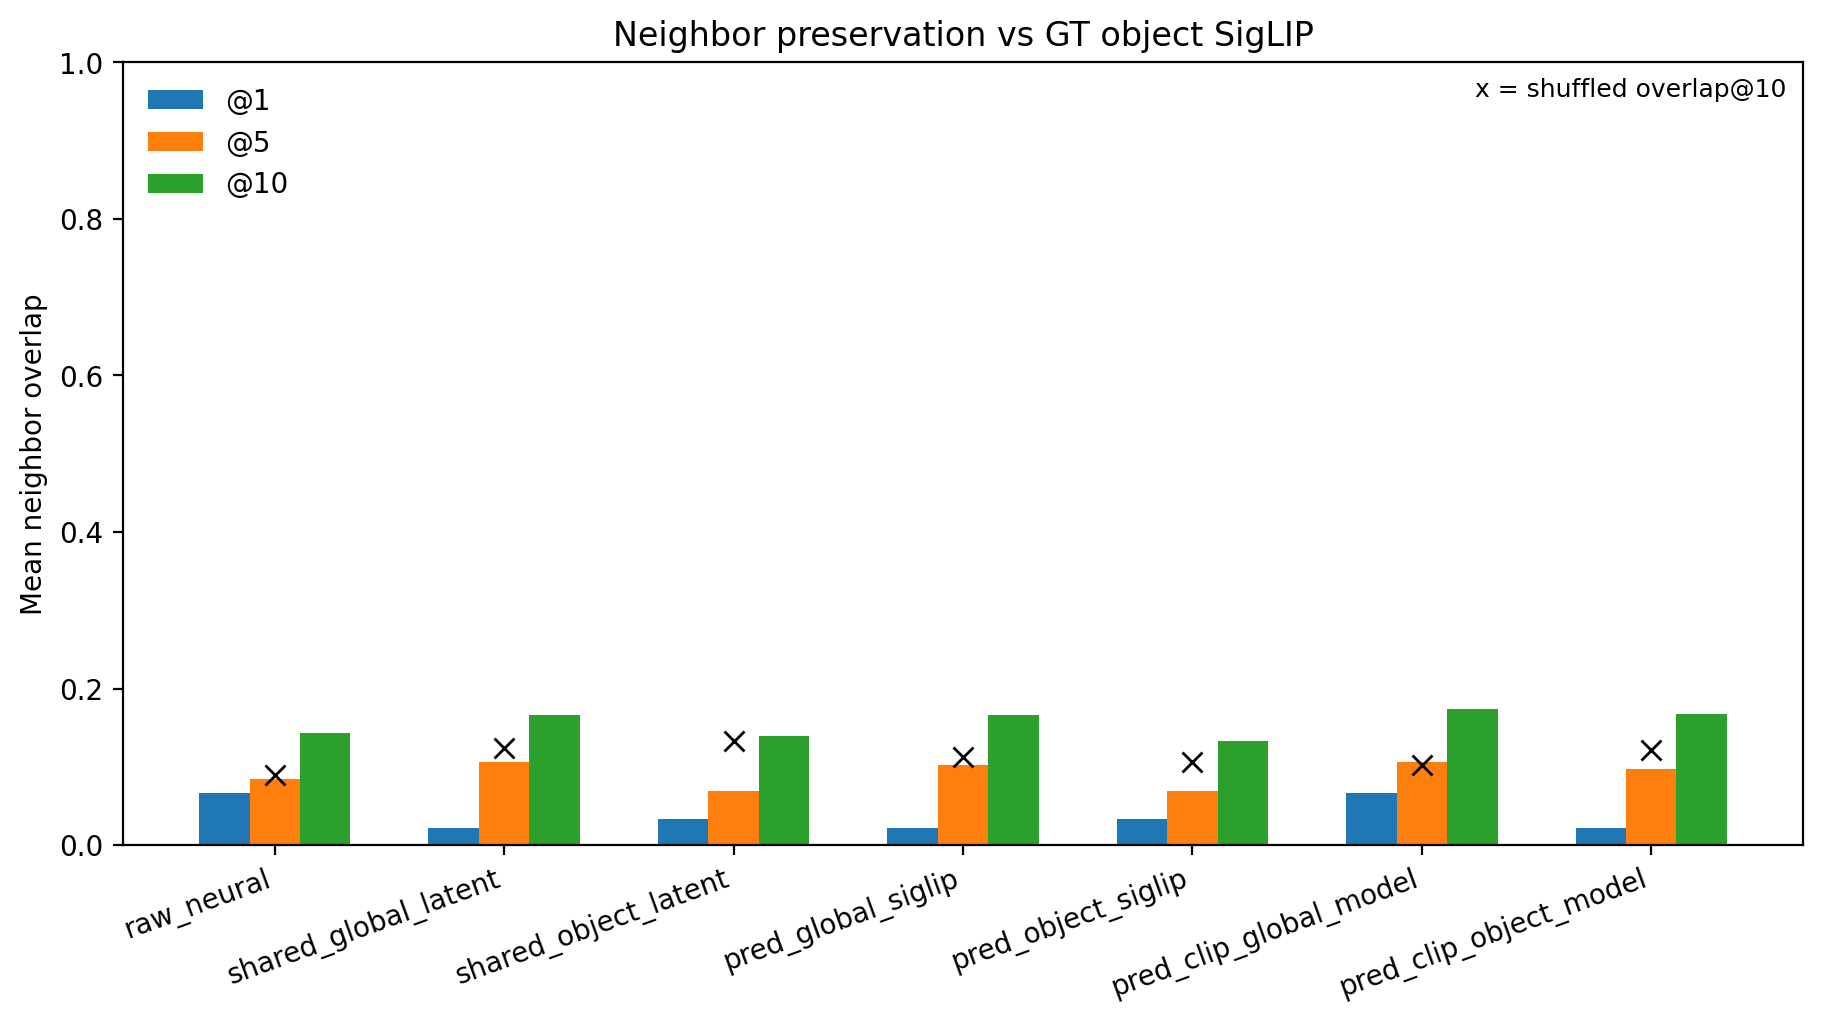

In [20]:
fig_nn_global = plot_nn_overlap(
    nn_summary,
    "gt_global_siglip",
    "Neighbor preservation vs GT global SigLIP",
)
display(fig_nn_global)

fig_nn_object = plot_nn_overlap(
    nn_summary,
    "gt_object_siglip",
    "Neighbor preservation vs GT object SigLIP",
)
display(fig_nn_object)

## Optional Save

This cell writes files only if `SAVE_RESULTS = True`.

In [21]:
if SAVE_RESULTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    rsa_summary.to_csv(OUT_DIR / "rsa_summary.csv", index=False)
    nn_summary.to_csv(OUT_DIR / "nn_overlap_summary.csv", index=False)
    fig_all.savefig(OUT_DIR / "rsa_heatmap_all_pairs.png", dpi=200)
    fig_within.savefig(OUT_DIR / "rsa_heatmap_within_category.png", dpi=200)
    fig_nn_global.savefig(OUT_DIR / "nn_overlap_global_siglip.png", dpi=200)
    fig_nn_object.savefig(OUT_DIR / "nn_overlap_object_siglip.png", dpi=200)
    print(f"Wrote embedding-geometry outputs to {OUT_DIR}")
else:
    print("SAVE_RESULTS is False; no files were written.")

SAVE_RESULTS is False; no files were written.
